In [4]:
# notebooks/03_modeling.ipynb

import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydantic\_internal\_fields.py:160: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


In [5]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8278, 30)
Test shape: (1409, 30)


In [6]:
mlflow.set_experiment("ChurnSense_Model_Comparison")

<Experiment: artifact_location='file:///f:/churnSense/churnsense/notebooks/mlruns/1', creation_time=1776247051943, experiment_id='1', last_update_time=1776247051943, lifecycle_stage='active', name='ChurnSense_Model_Comparison', tags={}, trace_location=None, workspace='default'>

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

In [8]:
results = []

for name, model in models.items():
    
    with mlflow.start_run(run_name=name):
        
        # Train
        model.fit(X_train, y_train)
        
        # Predictions
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc = roc_auc_score(y_test, y_prob)
        
        # Log metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", roc)
        
        # Log model
        mlflow.sklearn.log_model(model, name)
        
        # Save results
        results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1,
            "ROC-AUC": roc
        })
        
        print(f"✅ {name} trained")

2026/04/15 16:57:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 16:57:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logistic Regression trained


2026/04/15 16:58:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 16:58:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Random Forest trained


c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:58:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/04/15 16:59:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 16:59:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ XGBoost trained
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4139, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004403 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4856
[LightGBM] [Info] Number of data points in the train set: 8278, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


2026/04/15 16:59:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 16:59:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ LightGBM trained


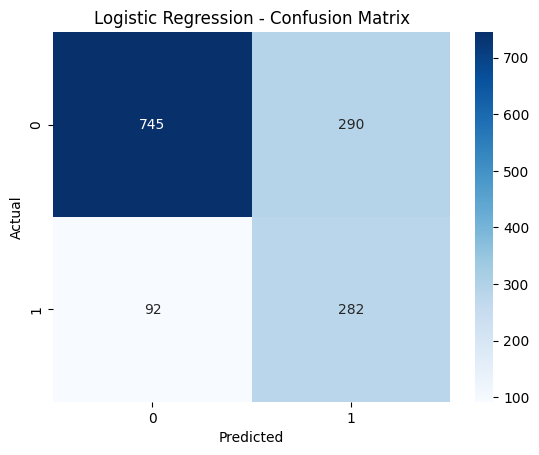

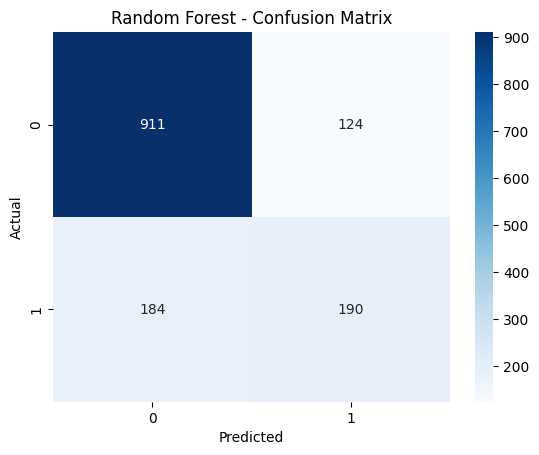

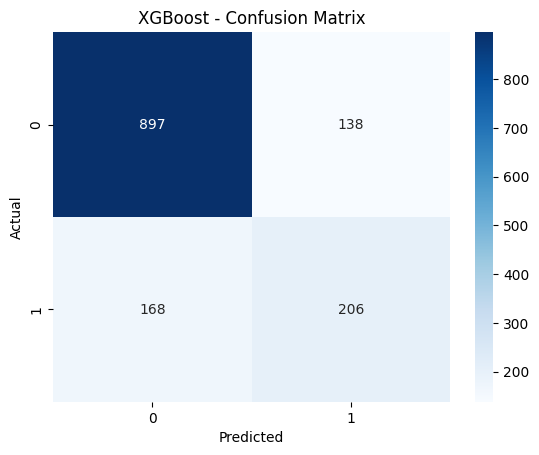

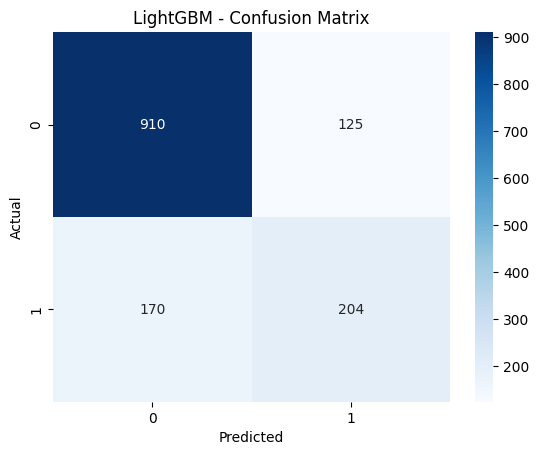

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [10]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,LightGBM,0.790632,0.620061,0.545455,0.580370,0.830587
0,Logistic Regression,0.728886,0.493007,0.754011,0.596195,0.827583
2,XGBoost,0.782825,0.598837,0.550802,0.573816,0.824967
1,Random Forest,0.781405,0.605096,0.508021,0.552326,0.819393


In [11]:
# ✅ SAFE SAVE (FIXED PATH)
import os
import pickle

# Set correct base path (your main project folder)
base_path = os.path.abspath(".")

model_path = os.path.join(base_path, "models")
os.makedirs(model_path, exist_ok=True)

# Save best model
with open(os.path.join(model_path, "best_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)

# Save scaler
with open(os.path.join(model_path, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

# Save encoder
with open(os.path.join(model_path, "encoder.pkl"), "wb") as f:
    pickle.dump(encoder, f)

print("✅ Models saved in:", model_path)

NameError: name 'best_model' is not defined